# JUMP-SCOPE → AnnData

The JUMP-MOA plate imaged across different microscopes and settings ([`cpg0002`](https://broadinstitute.github.io/cellpainting-gallery/)). Batches correspond to imaging configurations, so they share almost no features and one batch is used.

One observation is a well, one variable is a CellProfiler feature.
Well-level profiles only, no images:

```bash
aws s3 cp --no-sign-request --recursive --exclude "*" --include "*_normalized_feature_select_negcon_batch.csv.gz" \
  s3://cellpainting-gallery/cpg0002-jump-scope/source_4/workspace/profiles/ .
```

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import scanpy as sc

import cell_painting_io as cpio

PROFILES = Path("~/data/cpg0002-jump-scope/profiles").expanduser()

## Scoping to one batch

Feature selection ran per batch, so batches carry different feature sets and intersecting across them throws most features away.
This takes the batch with the most plates.

In [2]:
batches = sorted({p.parents[1].name for p in PROFILES.glob("*/*/*.csv.gz")})
BATCH = max(batches, key=lambda b: len(list((PROFILES / b).glob("*/*"))))
print(f"{len(batches)} batches, using {BATCH}")
files = sorted((PROFILES / BATCH).glob("*/*"))

85 batches, using 1siteSubSample_Scope1_PE_Bin1_Confocal_1Plane


In [3]:
adata = cpio.read_profiles(
    files, index_columns=["batch", "Plate", "Well"], path_columns={"batch": 2}, on_column_mismatch="intersect"
)
adata

/home/lheumos/code/cell-painting-io/cell_painting_io.py:58: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame[name] = path.parents[depth - 1].name
/home/lheumos/code/cell-painting-io/cell_painting_io.py:58: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame[name] = path.parents[depth - 1].name
/home/lheumos/code/cell-painting-io/cell_painting_io.py:58: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns 

AnnData object with n_obs × n_vars = 1529 × 823
    obs: 'broad_sample', 'solvent', 'Plate', 'Well', 'Site_Count', 'Count_Cells', 'Count_Cytoplasm', 'Count_Nuclei', 'Object_Count', 'InChIKey', 'pert_iname', 'pubchem_cid', 'moa', 'pert_type', 'control_type', 'smiles', 'batch'
    layers: None (.X)

In [4]:
cpio.annotate_features(adata.var)
adata = cpio.drop_incomplete_features(adata)
adata = cpio.drop_extreme_features(adata)
adata = cpio.drop_constant_features(adata)


def present(columns):
    return [c for c in columns if c in adata.obs.columns and adata.obs[c].nunique() > 1]


cpio.categorize(adata, present(["Plate", "pert_type", "control_type"]))
adata.var

,compartment,family,channel,channel_2,n_channels
feature,,,,,
Image_Granularity_10_ER,image,granularity,er,NaN,1
Image_Granularity_10_Mito,image,granularity,mito,NaN,1
Image_Granularity_10_RNA,image,granularity,rna,NaN,1
Image_Granularity_10_WGPhalloidin,image,granularity,NaN,NaN,0
Image_Granularity_11_ER,image,granularity,er,NaN,1
...,...,...,...,...,...
Nuclei_Texture_SumVariance_ER_20_01_256,nuclei,texture,er,NaN,1
Nuclei_Texture_SumVariance_Mito_20_03_256,nuclei,texture,mito,NaN,1
Nuclei_Texture_SumVariance_WGPhalloidin_20_01_256,nuclei,texture,NaN,NaN,0


## Sanity checks

In [5]:
print(f"{adata.n_obs:,} wells x {adata.n_vars:,} features")
print(f"non-finite: {int((~np.isfinite(adata.X)).sum())} | max|x|: {np.abs(adata.X).max():.1f}")
for column in present(["pert_type"]):
    print(f"\n{column}:")
    print(adata.obs[column].value_counts(dropna=False).head(6).to_string())

1,529 wells x 819 features
non-finite: 0 | max|x|: 20018.0

pert_type:
pert_type
trt        1433
control      96


In [6]:
adata.write_h5ad(PROFILES.parent / "jump_scope.h5ad")

## UMAP

The profiles are already normalized, so they enter PCA unscaled.

In [7]:
sc.pp.pca(adata, n_comps=min(50, adata.n_vars - 1))
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


How often do neighbouring wells share a label, against the rate expected if labels were shuffled?
Above 1 means the covariate explains part of the embedding.

In [8]:
cpio.neighbour_enrichment(adata, present(["Plate", "pert_type", "Site_Count"]))

,observed,baseline,ratio
covariate,,,
Plate,0.392,0.250,1.570
pert_type,0.861,0.882,0.975


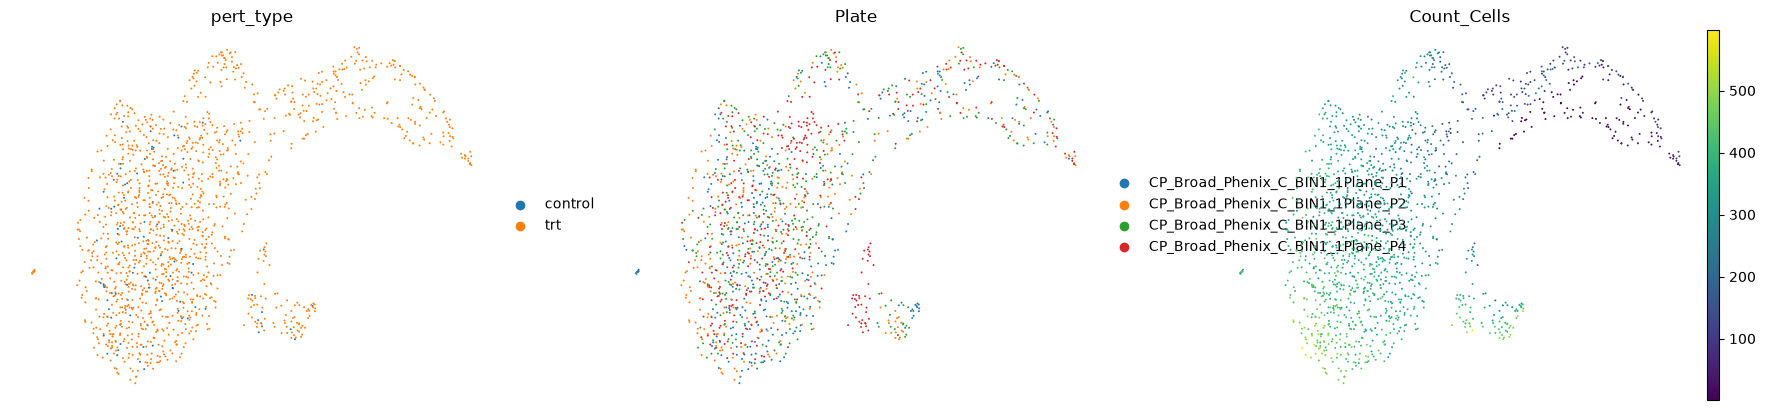

In [9]:
sc.pl.umap(adata, color=present(["pert_type", "Plate", "Count_Cells"])[:3], ncols=3, frameon=False, size=8)